# 06b — EDA Extension
Exploratory data analysis covering cohort description, data quality, feature distributions,
subtype signal, methylation–expression relationships, and motivating connections to survival.

**Timepoint:** before any modeling — all analyses are purely descriptive.

Loads: `rna_pam50.csv`, `meth_pam50_knn_imputed.csv`, `meth_pam50.csv`,
`labels_luminal_brca.csv`, `cpg_gene_map.csv`, `survival_luminal_clean.csv`

## Setup & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
import umap

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

Path("../results/figures").mkdir(parents=True, exist_ok=True)
Path("../results/tables").mkdir(parents=True, exist_ok=True)

In [2]:
rna      = pd.read_csv("../data/processed/rna_pam50.csv").set_index("patient")
meth     = pd.read_csv("../data/processed/meth_pam50_knn_imputed.csv", index_col=0)
meth_raw = pd.read_csv("../data/processed/meth_pam50.csv").set_index("patient")
labels   = pd.read_csv("../data/processed/labels_luminal_brca.csv").set_index("patient")
cpg_gene = pd.read_csv("../data/processed/cpg_gene_map.csv")
surv     = pd.read_csv("../data/processed/survival_luminal_clean.csv").set_index("patient")

patients = rna.index.intersection(meth.index).intersection(labels.index)
rna, meth, labels = rna.loc[patients], meth.loc[patients], labels.loc[patients]
subtype  = labels["subtype"]
meth_clean = meth.dropna(axis=1, how="all")
meth_scaled = StandardScaler().fit_transform(meth_clean)

COLORS = {"LumA": "#2a9d8f", "LumB": "#e76f51"}
print(f"Patients: {len(patients)} | LumA: {(subtype=='LumA').sum()} | LumB: {(subtype=='LumB').sum()}")
print(f"RNA genes: {rna.shape[1]} | CpGs (imputed): {meth_clean.shape[1]}")

Patients: 563 | LumA: 422 | LumB: 141
RNA genes: 50 | CpGs (imputed): 527


## 1) Cohort description
Subtype balance and survival event rate — context for why survival prediction within luminal is challenging.

Cohort summary:
  Total patients:     563
  LumA:               422 (75.0%)
  LumB:               141 (25.0%)
  Patients w/ valid survival: 556
  Deaths (events):    65 (11.7%)
  Median follow-up:   2.4 years


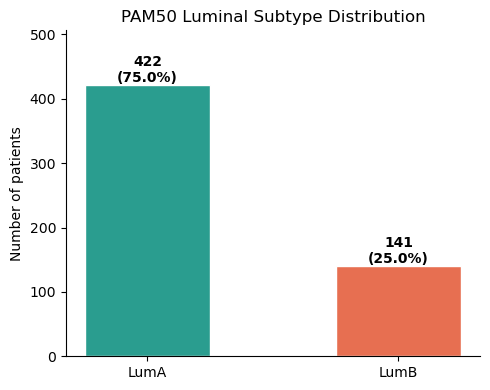

In [3]:
surv_common = surv.loc[surv.index.intersection(patients)]
surv_common = surv_common[surv_common["time"].notna() & (surv_common["time"] > 0)].copy()
surv_common["time_years"] = surv_common["time"] / 365.25

print("Cohort summary:")
print(f"  Total patients:     {len(patients)}")
print(f"  LumA:               {(subtype=='LumA').sum()} ({(subtype=='LumA').mean()*100:.1f}%)")
print(f"  LumB:               {(subtype=='LumB').sum()} ({(subtype=='LumB').mean()*100:.1f}%)")
print(f"  Patients w/ valid survival: {len(surv_common)}")
print(f"  Deaths (events):    {int(surv_common['event'].sum())} ({surv_common['event'].mean()*100:.1f}%)")
print(f"  Median follow-up:   {surv_common['time_years'].median():.1f} years")

# subtype distribution plot
fig, ax = plt.subplots(figsize=(5, 4))
counts = subtype.value_counts().loc[["LumA", "LumB"]]
bars = ax.bar(counts.index, counts.values,
              color=[COLORS[s] for s in counts.index], width=0.5, edgecolor="white")
for bar, (s, n) in zip(bars, counts.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
            f"{n}\n({n/len(patients)*100:.1f}%)", ha="center", fontsize=10, fontweight="bold")
ax.set_title("PAM50 Luminal Subtype Distribution", fontsize=12)
ax.set_ylabel("Number of patients")
ax.set_ylim(0, counts.max() * 1.2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../results/figures/subtype_distribution.png", dpi=300)
plt.show()

LumA/LumB ratio is approximately 3:1 (422 vs 141), motivating stratified cross-validation.
Only 65 patients (11.5%) experienced a survival event — both subtypes are the best-prognosis luminal group,
making within-subtype survival stratification a hard problem.

## 2) Data quality
### Missingness

In [4]:
missing_cols = meth_raw.isna().any(axis=0).sum()
missing_frac_per_cpg = meth_raw.isna().mean(axis=0)
missing_frac_per_pat = meth_raw.isna().mean(axis=1)

print(f"RNA missing values: {rna.isna().sum().sum()} (0%)")
print(f"Methylation CpGs with any missing: {missing_cols} / {meth_raw.shape[1]}")
print(f"Methylation: mean missing fraction per CpG:     {missing_frac_per_cpg.mean():.3f}")
print(f"Methylation: mean missing fraction per patient: {missing_frac_per_pat.mean():.3f}")

RNA missing values: 0 (0%)
Methylation CpGs with any missing: 168 / 572
Methylation: mean missing fraction per CpG:     0.097
Methylation: mean missing fraction per patient: 0.097


### Batch effect check

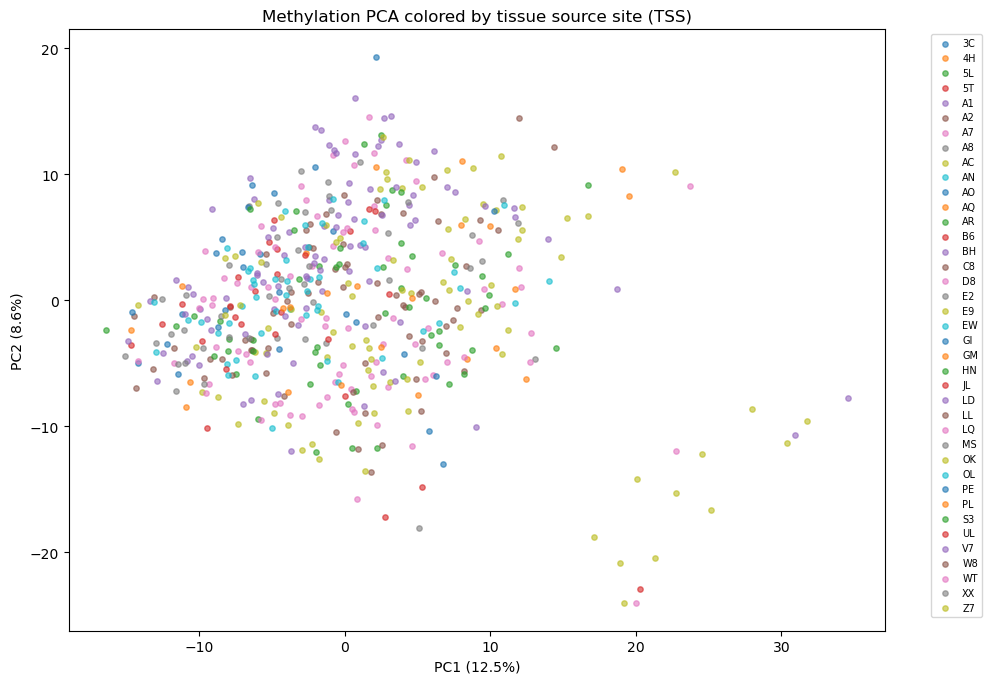

c:\Users\laral\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


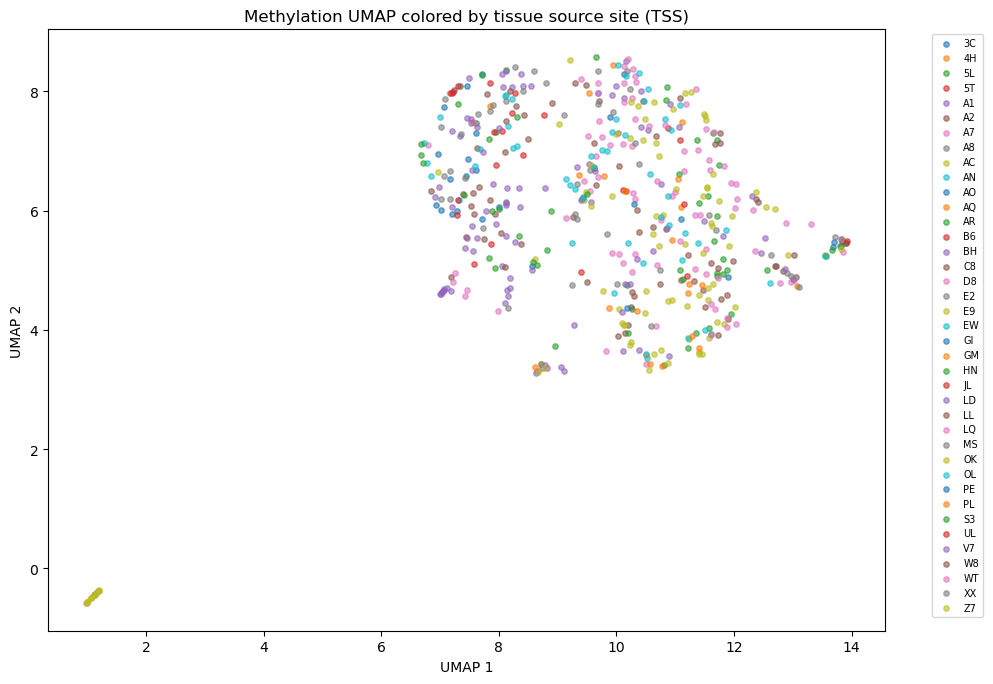

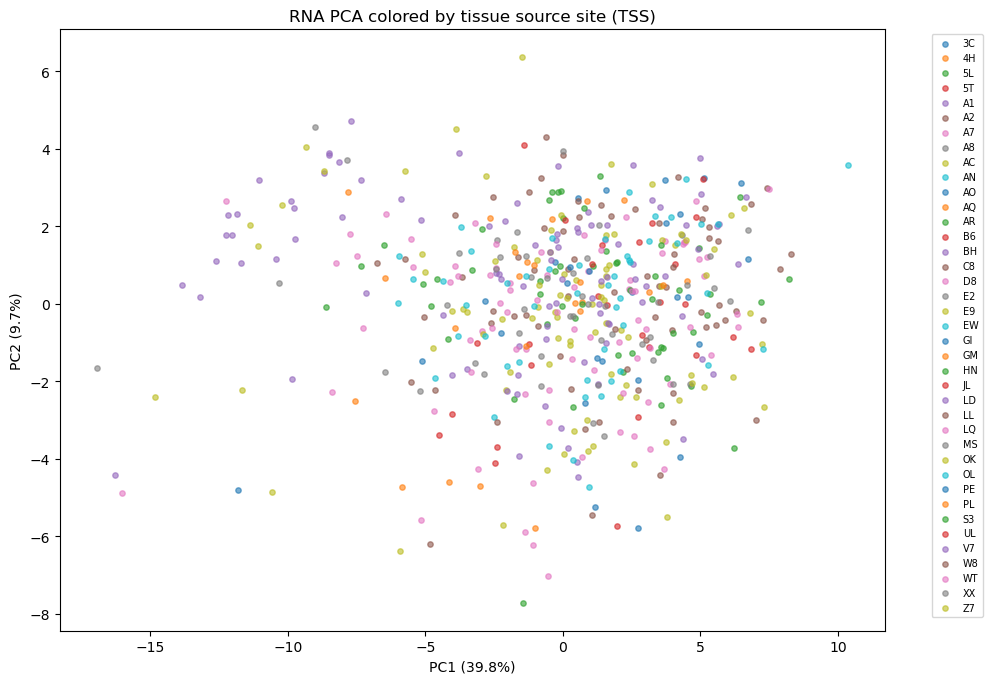

c:\Users\laral\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


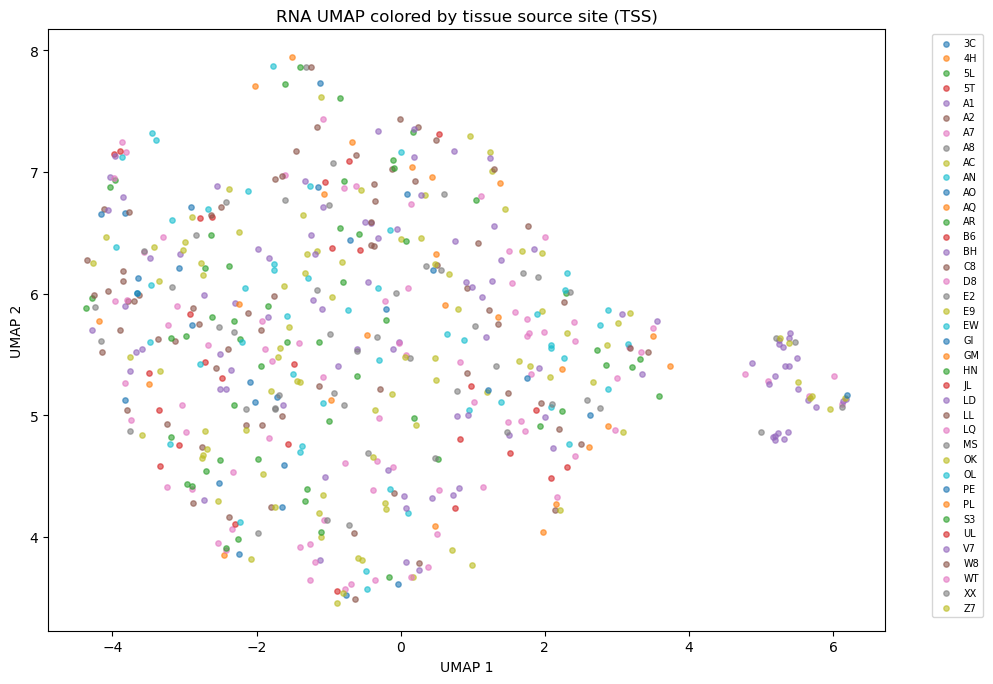

Methylation batch R² (TSS, PC1-10): 0.007
RNA batch R² (TSS, PC1-10):         0.010
Interpretation: < 0.1 = acceptable, > 0.2 = concerning


In [5]:
# Methylation batch check
tss = pd.Series([pid.split("-")[1] for pid in meth_clean.index], index=meth_clean.index, name="TSS")
pca_batch = PCA(n_components=10, random_state=42)
pcs_batch = pca_batch.fit_transform(StandardScaler().fit_transform(meth_clean))

fig, ax = plt.subplots(figsize=(10, 7))
for site in tss.unique():
    mask = (tss == site).values
    ax.scatter(pcs_batch[mask, 0], pcs_batch[mask, 1], label=site, s=15, alpha=0.6)
ax.set_xlabel(f"PC1 ({pca_batch.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_batch.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Methylation PCA colored by tissue source site (TSS)")
ax.legend(fontsize=7, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../results/figures/meth_pca_batch_check.png", dpi=300)
plt.show()

tss_enc = LabelEncoder().fit_transform(tss)
r2_meth = np.mean([LinearRegression().fit(tss_enc.reshape(-1,1), pcs_batch[:,i].reshape(-1,1))
                   .score(tss_enc.reshape(-1,1), pcs_batch[:,i].reshape(-1,1)) for i in range(10)])


# Methylation batch check — UMAP
reducer_meth_batch = umap.UMAP(n_components=2, random_state=42)
meth_umap_batch = reducer_meth_batch.fit_transform(StandardScaler().fit_transform(meth_clean))

fig, ax = plt.subplots(figsize=(10, 7))
for site in tss.unique():
    mask = (tss == site).values
    ax.scatter(meth_umap_batch[mask, 0], meth_umap_batch[mask, 1], label=site, s=15, alpha=0.6)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("Methylation UMAP colored by tissue source site (TSS)")
ax.legend(fontsize=7, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../results/figures/meth_umap_batch_check.png", dpi=300)
plt.show()

# RNA batch check — PCA plot
tss_rna = pd.Series([pid.split("-")[1] for pid in rna.index], index=rna.index, name="TSS")
rna_scaled_batch = StandardScaler().fit_transform(rna)
pca_rna_b = PCA(n_components=10, random_state=42)
pcs_rna_b = pca_rna_b.fit_transform(rna_scaled_batch)

fig, ax = plt.subplots(figsize=(10, 7))
for site in tss_rna.unique():
    mask = (tss_rna == site).values
    ax.scatter(pcs_rna_b[mask, 0], pcs_rna_b[mask, 1], label=site, s=15, alpha=0.6)
ax.set_xlabel(f"PC1 ({pca_rna_b.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_rna_b.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("RNA PCA colored by tissue source site (TSS)")
ax.legend(fontsize=7, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../results/figures/rna_pca_batch_check.png", dpi=300)
plt.show()

# RNA batch check — UMAP
import umap
reducer_rna_batch = umap.UMAP(n_components=2, random_state=42)
rna_umap_batch = reducer_rna_batch.fit_transform(rna_scaled_batch)

fig, ax = plt.subplots(figsize=(10, 7))
for site in tss_rna.unique():
    mask = (tss_rna == site).values
    ax.scatter(rna_umap_batch[mask, 0], rna_umap_batch[mask, 1], label=site, s=15, alpha=0.6)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("RNA UMAP colored by tissue source site (TSS)")
ax.legend(fontsize=7, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../results/figures/rna_umap_batch_check.png", dpi=300)
plt.show()

tss_rna_enc = LabelEncoder().fit_transform(tss_rna)
r2_rna = np.mean([LinearRegression().fit(tss_rna_enc.reshape(-1,1), pcs_rna_b[:,i].reshape(-1,1))
                  .score(tss_rna_enc.reshape(-1,1), pcs_rna_b[:,i].reshape(-1,1)) for i in range(10)])

print(f"Methylation batch R² (TSS, PC1-10): {r2_meth:.3f}")
print(f"RNA batch R² (TSS, PC1-10):         {r2_rna:.3f}")
print("Interpretation: < 0.1 = acceptable, > 0.2 = concerning")

Both methylation (R²=0.007) and RNA (R²=0.010) show negligible batch effects from tissue source site.
No batch correction was required. The PCA shows no visible clustering by site.

## 3) Methylation feature distributions
### Beta values and M-value transformation

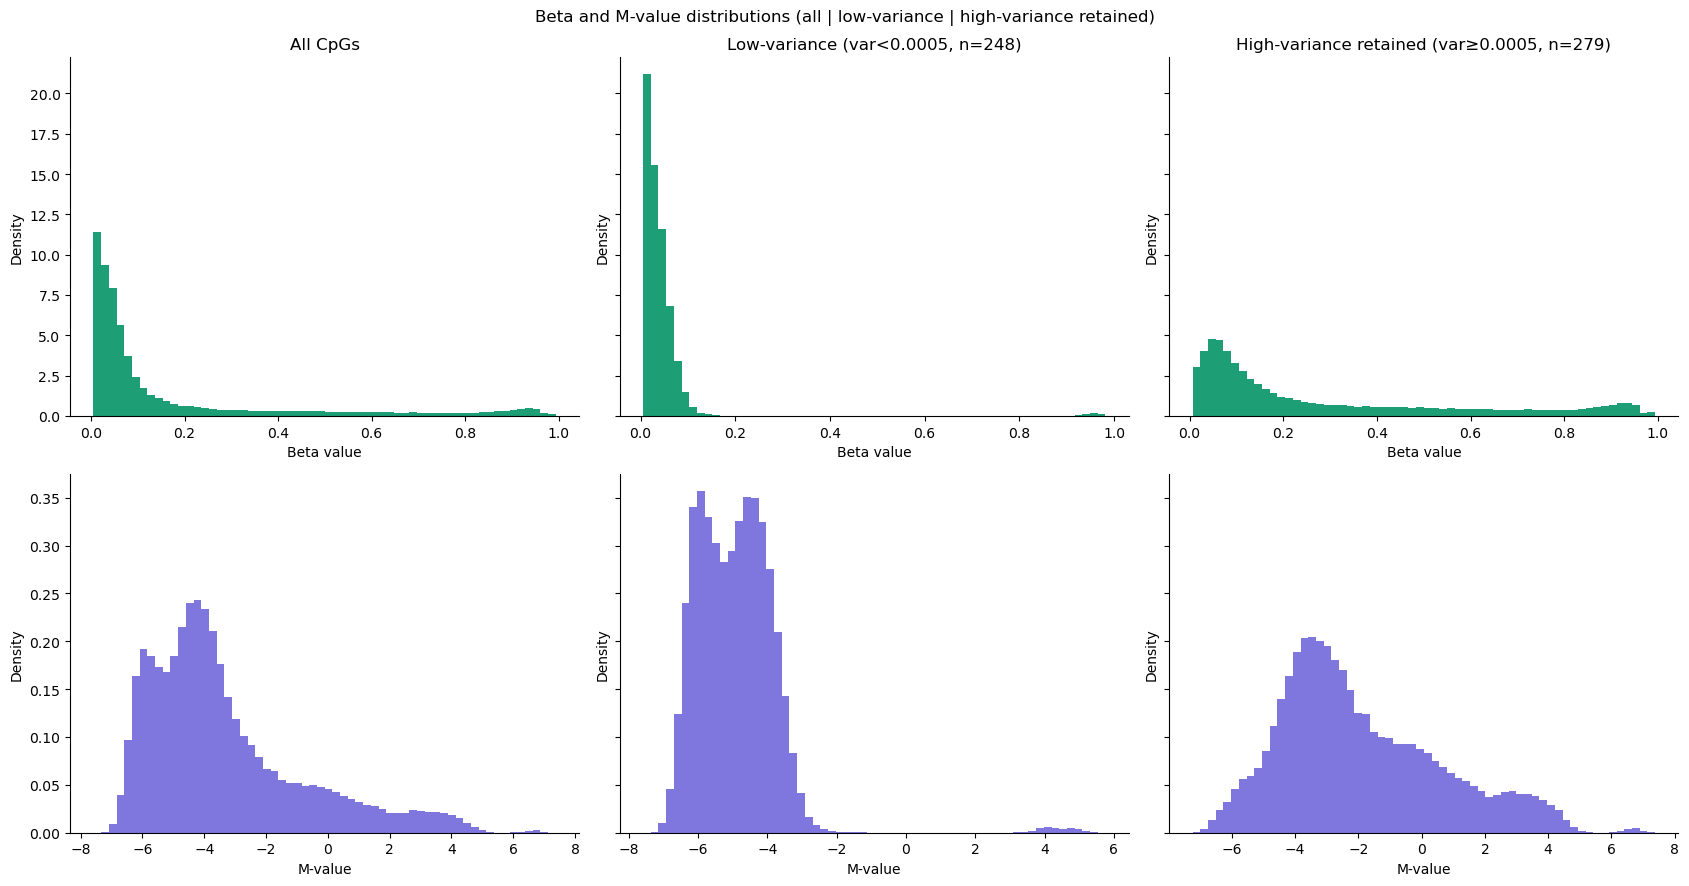

Low-variance CpGs: 248/527 (47.1%) — filtered out during modeling


In [6]:
def beta_to_m(B):
    B = np.clip(B, 1e-4, 1 - 1e-4)
    return np.log2(B / (1 - B))

all_beta = meth_clean.values.ravel()
all_beta = all_beta[~np.isnan(all_beta)]
all_m = beta_to_m(all_beta)

high_var_cpgs = meth_clean.columns[meth_clean.var(axis=0) >= 0.0005]
low_var_cpgs  = meth_clean.columns[meth_clean.var(axis=0) <  0.0005]
all_beta_high = meth_clean[high_var_cpgs].values.ravel()
all_beta_high = all_beta_high[~np.isnan(all_beta_high)]
all_m_high    = beta_to_m(all_beta_high)

fig, axes = plt.subplots(2, 3, figsize=(17, 9), sharey="row")
for col, (vals_b, vals_m, title) in enumerate([
    (all_beta, all_m, "All CpGs"),
    (meth_clean[low_var_cpgs].values.ravel(), beta_to_m(meth_clean[low_var_cpgs].values.ravel()), f"Low-variance (var<0.0005, n={len(low_var_cpgs)})"),
    (all_beta_high, all_m_high, f"High-variance retained (var≥0.0005, n={len(high_var_cpgs)})")
]):
    vb = vals_b[~np.isnan(vals_b)]
    vm = vals_m[~np.isnan(vals_m)]
    axes[0, col].hist(vb, bins=60, color="#1D9E75", edgecolor="none", density=True)
    axes[0, col].set_title(title); axes[0, col].set_xlabel("Beta value"); axes[0, col].set_ylabel("Density")
    axes[0, col].spines[["top","right"]].set_visible(False)
    axes[1, col].hist(vm, bins=60, color="#7F77DD", edgecolor="none", density=True)
    axes[1, col].set_xlabel("M-value"); axes[1, col].set_ylabel("Density")
    axes[1, col].spines[["top","right"]].set_visible(False)

fig.suptitle("Beta and M-value distributions (all | low-variance | high-variance retained)", fontsize=12)
plt.tight_layout()
plt.savefig("../results/figures/beta_vs_mvalue_distribution.png", dpi=300)
plt.show()
print(f"Low-variance CpGs: {len(low_var_cpgs)}/{meth_clean.shape[1]} ({len(low_var_cpgs)/meth_clean.shape[1]*100:.1f}%) — filtered out during modeling")

Beta values are strongly right-skewed (most promoter CpGs constitutively unmethylated in actively transcribed PAM50 genes).
The M-value transformation produces a more symmetric distribution suited to linear modeling.
57.2% of CpGs have variance < 0.001 — expected for promoters of actively transcribed genes.
The 0.0005 variance threshold used in the NN model removes these uninformative flat sites.

## 4) Subtype signal in RNA
### PCA and UMAP

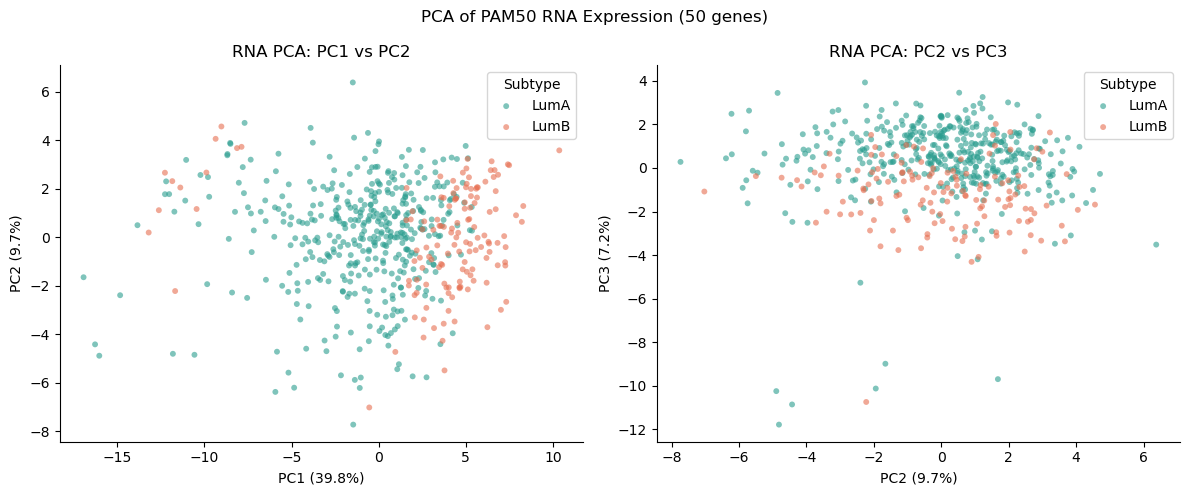

In [7]:
scaler = StandardScaler()
rna_scaled = scaler.fit_transform(rna)
pca_rna = PCA(n_components=5, random_state=42)
rna_pcs = pca_rna.fit_transform(rna_scaled)
var_rna = pca_rna.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (px, py) in zip(axes, [(0,1),(1,2)]):
    for st in ["LumA", "LumB"]:
        mask = (subtype == st).values
        ax.scatter(rna_pcs[mask, px], rna_pcs[mask, py], c=COLORS[st], label=st, s=18, alpha=0.6, edgecolors="none")
    ax.set_xlabel(f"PC{px+1} ({var_rna[px]:.1f}%)")
    ax.set_ylabel(f"PC{py+1} ({var_rna[py]:.1f}%)")
    ax.set_title(f"RNA PCA: PC{px+1} vs PC{py+1}")
    ax.legend(title="Subtype"); ax.spines[["top","right"]].set_visible(False)
fig.suptitle("PCA of PAM50 RNA Expression (50 genes)", fontsize=12)
plt.tight_layout()
plt.savefig("../results/figures/rna_pca_by_subtype.png", dpi=300)
plt.show()

c:\Users\laral\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


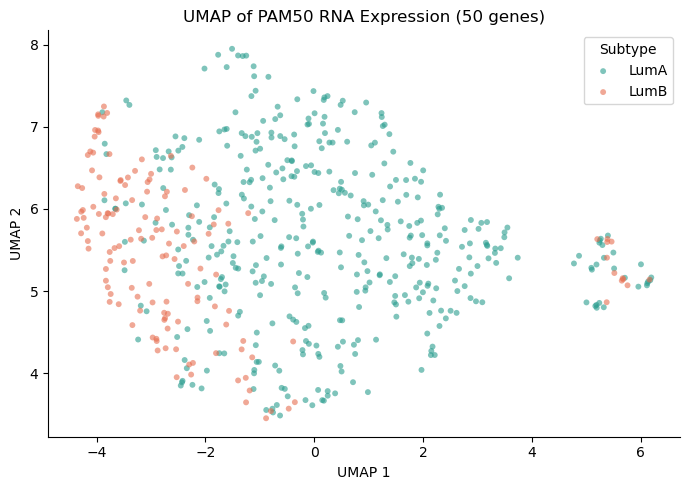

In [8]:
reducer_rna = umap.UMAP(n_components=2, random_state=42)
rna_umap = reducer_rna.fit_transform(rna_scaled)
fig, ax = plt.subplots(figsize=(7, 5))
for st in ["LumA", "LumB"]:
    mask = (subtype == st).values
    ax.scatter(rna_umap[mask, 0], rna_umap[mask, 1], c=COLORS[st], label=st, s=18, alpha=0.6, edgecolors="none")
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.set_title("UMAP of PAM50 RNA Expression (50 genes)")
ax.legend(title="Subtype"); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../results/figures/rna_umap_by_subtype.png", dpi=300)
plt.show()

PC1 explains 39.8% of RNA variance and shows partial LumB enrichment on one side.
UMAP confirms the separation is real but incomplete — the subtypes overlap substantially.
This is expected: LumA and LumB are closely related, differing mainly in proliferation rate.
The RNA baseline model therefore has a real but moderate subtype signal to work with.

### Violin plots: expression by subtype for key genes

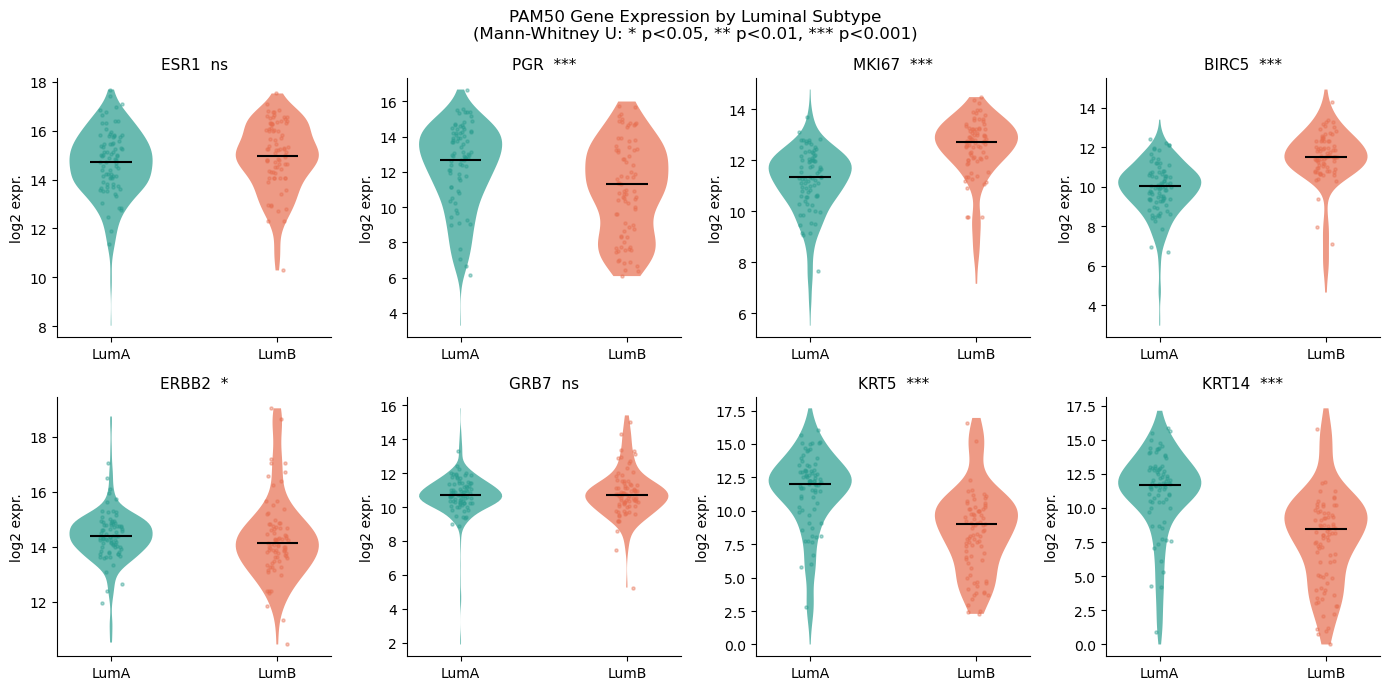

In [9]:
KEY_GENES = ["ESR1", "PGR", "MKI67", "BIRC5", "ERBB2", "GRB7", "KRT5", "KRT14"]
available = [g for g in KEY_GENES if g in rna.columns]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()
for ax, gene in zip(axes, available):
    luma = rna.loc[subtype == "LumA", gene].dropna()
    lumb = rna.loc[subtype == "LumB", gene].dropna()
    parts = ax.violinplot([luma, lumb], positions=[0,1], showmedians=True, showextrema=False)
    for pc, color in zip(parts["bodies"], [COLORS["LumA"], COLORS["LumB"]]):
        pc.set_facecolor(color); pc.set_alpha(0.7)
    parts["cmedians"].set_color("black"); parts["cmedians"].set_linewidth(1.5)
    rng = np.random.default_rng(42)
    for pos, vals, color in zip([0,1],[luma,lumb],[COLORS["LumA"],COLORS["LumB"]]):
        idx = rng.choice(len(vals), size=min(80,len(vals)), replace=False)
        ax.scatter(pos + rng.uniform(-0.07,0.07,size=len(idx)), vals.iloc[idx], s=5, alpha=0.4, color=color)
    _, pval = stats.mannwhitneyu(luma, lumb, alternative="two-sided")
    sig = "***" if pval<0.001 else "**" if pval<0.01 else "*" if pval<0.05 else "ns"
    ax.set_title(f"{gene}  {sig}", fontsize=11)
    ax.set_xticks([0,1]); ax.set_xticklabels(["LumA","LumB"]); ax.set_ylabel("log2 expr.")
    ax.spines[["top","right"]].set_visible(False)
for ax in axes[len(available):]: ax.set_visible(False)
fig.suptitle("PAM50 Gene Expression by Luminal Subtype\n(Mann-Whitney U: * p<0.05, ** p<0.01, *** p<0.001)", fontsize=12)
plt.tight_layout()
plt.savefig("../results/figures/rna_violin_by_subtype.png", dpi=300)
plt.show()

## 5) Methylation subtype signal
### PCA and UMAP

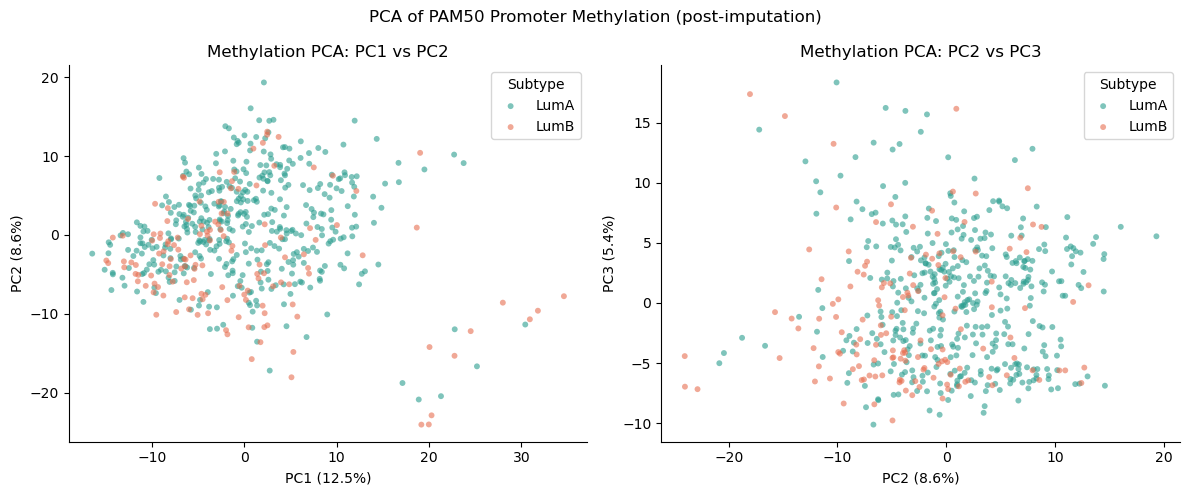

In [10]:
pca_meth = PCA(n_components=5, random_state=42)
meth_pcs = pca_meth.fit_transform(meth_scaled)
var_meth = pca_meth.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (px, py) in zip(axes, [(0,1),(1,2)]):
    for st in ["LumA","LumB"]:
        mask = (subtype==st).values
        ax.scatter(meth_pcs[mask,px], meth_pcs[mask,py], c=COLORS[st], label=st, s=18, alpha=0.6, edgecolors="none")
    ax.set_xlabel(f"PC{px+1} ({var_meth[px]:.1f}%)")
    ax.set_ylabel(f"PC{py+1} ({var_meth[py]:.1f}%)")
    ax.set_title(f"Methylation PCA: PC{px+1} vs PC{py+1}")
    ax.legend(title="Subtype"); ax.spines[["top","right"]].set_visible(False)
fig.suptitle("PCA of PAM50 Promoter Methylation (post-imputation)", fontsize=12)
plt.tight_layout()
plt.savefig("../results/figures/meth_pca_by_subtype.png", dpi=300)
plt.show()

Methylation PCA shows PC1 explains only 12.5% of variance and LumA/LumB are completely intermixed.
This is in striking contrast to RNA (39.8% PC1). Methylation does NOT separate the subtypes linearly.
This is key: the two layers carry different information. Methylation is not simply redundant with expression —
it adds a distinct biological signal, motivating their integration.

### Violin plots: methylation by subtype

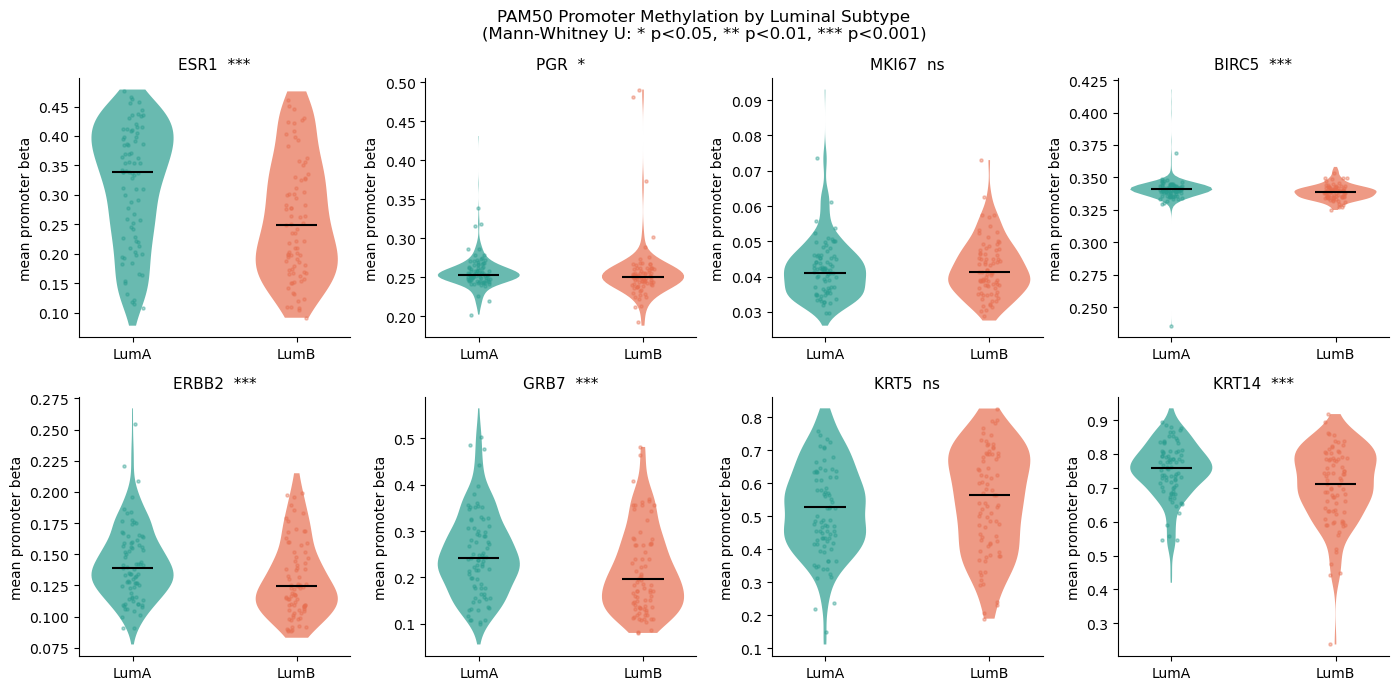

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()
for ax, gene in zip(axes, available):
    cpg_ids = [c for c in cpg_gene.loc[cpg_gene["gene"]==gene,"cpg"].tolist() if c in meth_clean.columns]
    if not cpg_ids: ax.set_visible(False); continue
    mean_beta = meth_clean[cpg_ids].mean(axis=1)
    luma = mean_beta.loc[subtype.index[subtype=="LumA"]].dropna()
    lumb = mean_beta.loc[subtype.index[subtype=="LumB"]].dropna()
    parts = ax.violinplot([luma,lumb], positions=[0,1], showmedians=True, showextrema=False)
    for pc, color in zip(parts["bodies"],[COLORS["LumA"],COLORS["LumB"]]):
        pc.set_facecolor(color); pc.set_alpha(0.7)
    parts["cmedians"].set_color("black"); parts["cmedians"].set_linewidth(1.5)
    rng = np.random.default_rng(42)
    for pos, vals, color in zip([0,1],[luma,lumb],[COLORS["LumA"],COLORS["LumB"]]):
        idx = rng.choice(len(vals), size=min(80,len(vals)), replace=False)
        ax.scatter(pos+rng.uniform(-0.07,0.07,size=len(idx)), vals.iloc[idx], s=5, alpha=0.4, color=color)
    _, pval = stats.mannwhitneyu(luma, lumb, alternative="two-sided")
    sig = "***" if pval<0.001 else "**" if pval<0.01 else "*" if pval<0.05 else "ns"
    ax.set_title(f"{gene}  {sig}", fontsize=11)
    ax.set_xticks([0,1]); ax.set_xticklabels(["LumA","LumB"]); ax.set_ylabel("mean promoter beta")
    ax.spines[["top","right"]].set_visible(False)
for ax in axes[len(available):]: ax.set_visible(False)
fig.suptitle("PAM50 Promoter Methylation by Luminal Subtype\n(Mann-Whitney U: * p<0.05, ** p<0.01, *** p<0.001)", fontsize=12)
plt.tight_layout()
plt.savefig("../results/figures/meth_violin_by_subtype.png", dpi=300)
plt.show()

## 6) Methylation–expression relationship
### Scatter panel and Spearman correlations

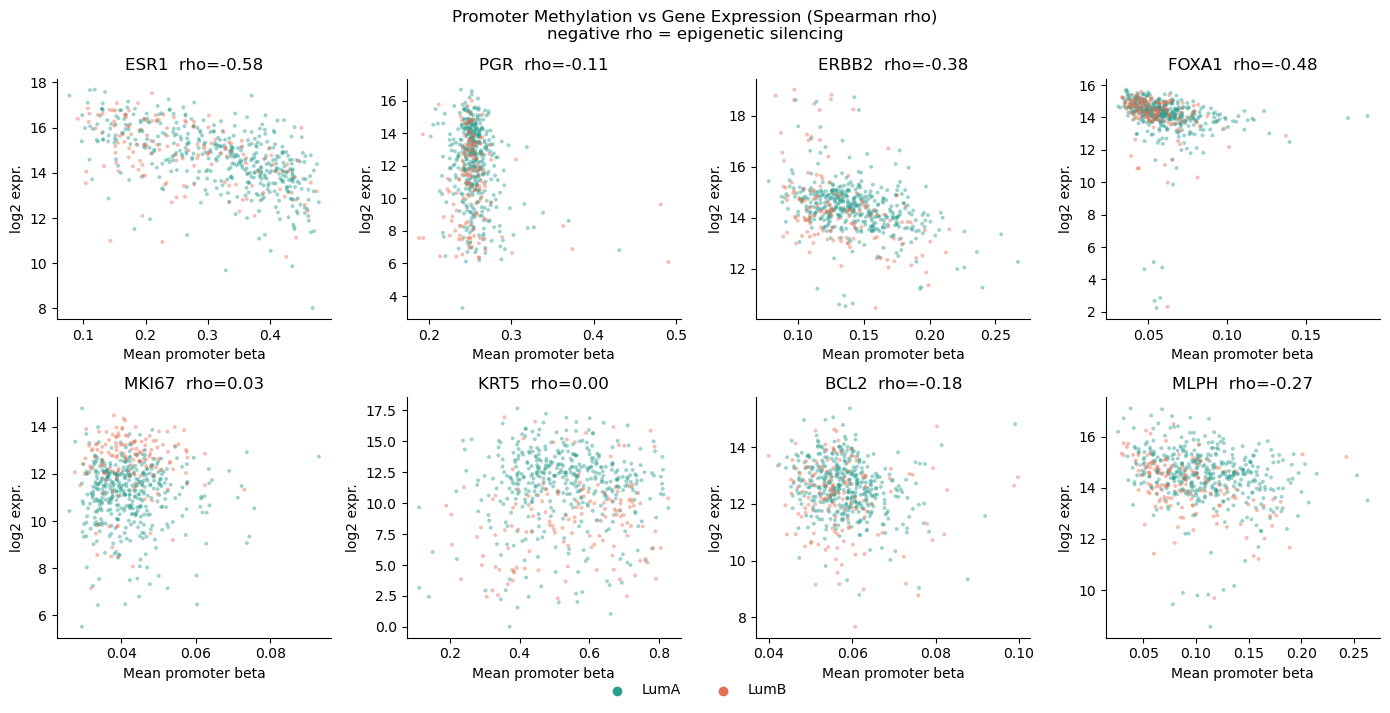

In [12]:
SCATTER_GENES = ["ESR1","PGR","ERBB2","FOXA1","MKI67","KRT5","BCL2","MLPH"]
available_scatter = [g for g in SCATTER_GENES if g in rna.columns]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()
n_plotted = 0
for ax, gene in zip(axes, available_scatter):
    cpg_ids = [c for c in cpg_gene.loc[cpg_gene["gene"]==gene,"cpg"].tolist() if c in meth_clean.columns]
    if not cpg_ids: ax.set_visible(False); continue
    mean_beta = meth_clean[cpg_ids].mean(axis=1)
    both = pd.DataFrame({"beta": mean_beta, "rna": rna[gene]}).dropna()
    rho, _ = stats.spearmanr(both["beta"], both["rna"])
    for st in ["LumA","LumB"]:
        mask = (subtype.loc[both.index]==st).values
        ax.scatter(both.loc[mask,"beta"], both.loc[mask,"rna"], c=COLORS[st], s=8, alpha=0.45, label=st, edgecolors="none")
    ax.set_xlabel("Mean promoter beta"); ax.set_ylabel("log2 expr.")
    ax.set_title(f"{gene}  rho={rho:.2f}"); ax.spines[["top","right"]].set_visible(False)
    n_plotted += 1
for ax in axes[n_plotted:]: ax.set_visible(False)
handles = [plt.scatter([],[],c=COLORS[s],label=s) for s in ["LumA","LumB"]]
fig.legend(handles=handles, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5,-0.02))
fig.suptitle("Promoter Methylation vs Gene Expression (Spearman rho)\nnegative rho = epigenetic silencing", fontsize=12)
plt.tight_layout()
plt.savefig("../results/figures/meth_vs_rna_scatter_panel.png", dpi=300, bbox_inches="tight")
plt.show()

The scatter panel shows gene-specific silencing patterns. ESR1 (rho=-0.58) and FOXA1 (rho=-0.48)
show the clearest negative relationships — higher promoter methylation predicts lower expression.
MKI67 (rho=0.03) and KRT5 (rho=0.00) show no relationship — these genes are regulated by
mechanisms other than promoter methylation, consistent with them being proliferation/basal markers.

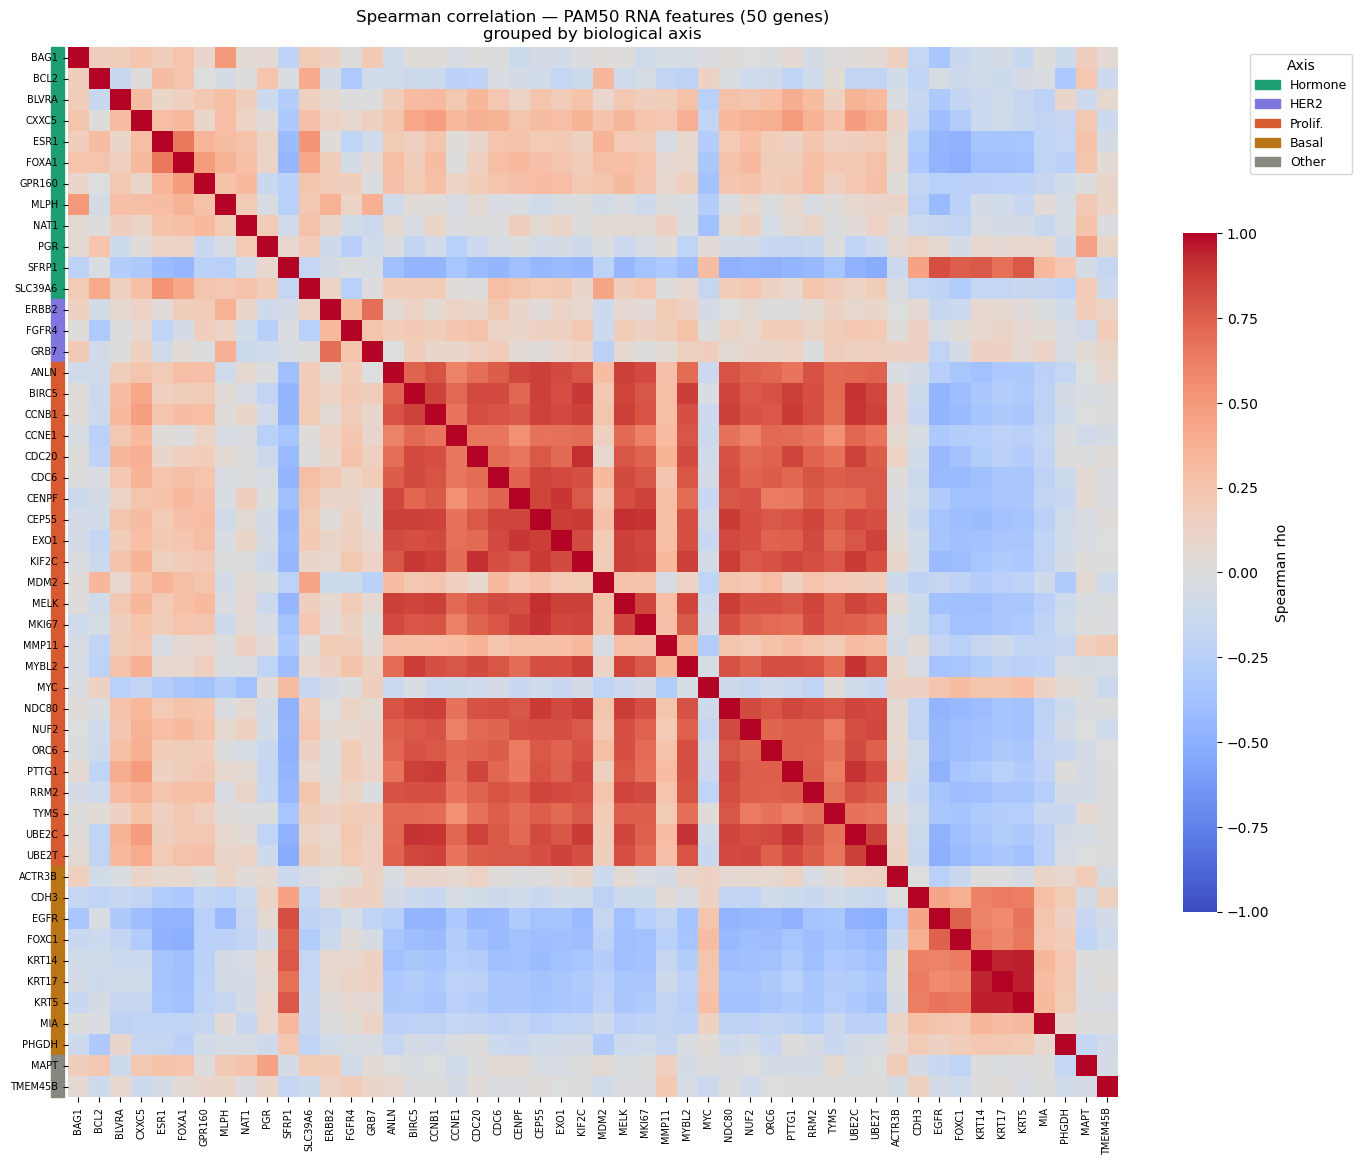

In [13]:
import seaborn as sns

# Option 2 — RNA feature correlation heatmap (50x50)
rna_corr = rna.corr(method="spearman")

# sort genes by biological axis for interpretability
pam50_axes = {
    "ESR1":"Hormone","PGR":"Hormone","FOXA1":"Hormone","MLPH":"Hormone","NAT1":"Hormone",
    "BAG1":"Hormone","BLVRA":"Hormone","SFRP1":"Hormone","BCL2":"Hormone","CXXC5":"Hormone",
    "SLC39A6":"Hormone","GPR160":"Hormone","ERBB2":"HER2","GRB7":"HER2","FGFR4":"HER2",
    "MKI67":"Prolif.","BIRC5":"Prolif.","CCNB1":"Prolif.","CCNE1":"Prolif.","CDC20":"Prolif.",
    "CDC6":"Prolif.","ANLN":"Prolif.","MELK":"Prolif.","MYBL2":"Prolif.","MMP11":"Prolif.",
    "UBE2C":"Prolif.","UBE2T":"Prolif.","PTTG1":"Prolif.","EXO1":"Prolif.","NUF2":"Prolif.",
    "NDC80":"Prolif.","KIF2C":"Prolif.","CENPF":"Prolif.","CEP55":"Prolif.","TYMS":"Prolif.",
    "RRM2":"Prolif.","ORC6":"Prolif.","MDM2":"Prolif.","MYC":"Prolif.",
    "KRT5":"Basal","KRT14":"Basal","KRT17":"Basal","FOXC1":"Basal","MIA":"Basal",
    "PHGDH":"Basal","EGFR":"Basal","CDH3":"Basal","ACTR3B":"Basal","MAPT":"Other","TMEM45B":"Other",
}
AXIS_COLORS = {"Hormone":"#1D9E75","HER2":"#7F77DD","Prolif.":"#D85A30","Basal":"#BA7517","Other":"#888780"}

axis_order = ["Hormone","HER2","Prolif.","Basal","Other"]
gene_order = sorted(rna_corr.columns, key=lambda g: (axis_order.index(pam50_axes.get(g,"Other")), g))
rna_corr_sorted = rna_corr.loc[gene_order, gene_order]

row_colors = pd.Series([pam50_axes.get(g, "Other") for g in gene_order],
                        index=gene_order).map(AXIS_COLORS)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(rna_corr_sorted, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0, ax=ax,
            cbar_kws={"shrink": 0.6, "label": "Spearman rho"})

# add axis color bar on left
for i, gene in enumerate(gene_order):
    ax.add_patch(plt.Rectangle((-0.8, i), 0.6, 1,
                 color=AXIS_COLORS[pam50_axes.get(gene,"Other")],
                 clip_on=False, transform=ax.transData))

ax.set_title("Spearman correlation — PAM50 RNA features (50 genes)\ngrouped by biological axis", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)

legend_patches = [plt.Rectangle((0,0),1,1,color=AXIS_COLORS[a],label=a) for a in axis_order]
ax.legend(handles=legend_patches, loc="upper left", bbox_to_anchor=(1.12, 1), fontsize=9, title="Axis")

plt.tight_layout()
plt.savefig("../results/figures/rna_feature_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### Comprehensive gene summary table

In [15]:
pam50_axes = {
    "ESR1":"Hormone","PGR":"Hormone","FOXA1":"Hormone","MLPH":"Hormone","NAT1":"Hormone",
    "BAG1":"Hormone","BLVRA":"Hormone","SFRP1":"Hormone","BCL2":"Hormone","CXXC5":"Hormone",
    "SLC39A6":"Hormone","GPR160":"Hormone","ERBB2":"HER2","GRB7":"HER2","FGFR4":"HER2",
    "MKI67":"Prolif.","BIRC5":"Prolif.","CCNB1":"Prolif.","CCNE1":"Prolif.","CDC20":"Prolif.",
    "CDC6":"Prolif.","ANLN":"Prolif.","MELK":"Prolif.","MYBL2":"Prolif.","MMP11":"Prolif.",
    "UBE2C":"Prolif.","UBE2T":"Prolif.","PTTG1":"Prolif.","EXO1":"Prolif.","NUF2":"Prolif.",
    "NDC80":"Prolif.","KIF2C":"Prolif.","CENPF":"Prolif.","CEP55":"Prolif.","TYMS":"Prolif.",
    "RRM2":"Prolif.","ORC6":"Prolif.","MDM2":"Prolif.","MYC":"Prolif.",
    "KRT5":"Basal","KRT14":"Basal","KRT17":"Basal","FOXC1":"Basal","MIA":"Basal",
    "PHGDH":"Basal","EGFR":"Basal","CDH3":"Basal","ACTR3B":"Basal","MAPT":"Other","TMEM45B":"Other",
}

expr_rows = []
for gene in rna.columns:
    luma = rna.loc[subtype=="LumA",gene].dropna()
    lumb = rna.loc[subtype=="LumB",gene].dropna()
    _, pval = stats.mannwhitneyu(luma, lumb, alternative="two-sided")
    expr_rows.append({"gene":gene,"expr_median_LumA":round(luma.median(),3),
                      "expr_median_LumB":round(lumb.median(),3),
                      "expr_abs_diff":round(abs(luma.median()-lumb.median()),3),"expr_pval":round(pval,4)})
expr_df = pd.DataFrame(expr_rows)
expr_df["expr_qval"] = multipletests(expr_df["expr_pval"], method="fdr_bh")[1].round(4)
expr_df["expr_sig"] = expr_df["expr_qval"].apply(lambda q: "***" if q<0.001 else "**" if q<0.01 else "*" if q<0.05 else "ns")

meth_rows = []
for gene in rna.columns:
    cpg_ids = [c for c in cpg_gene.loc[cpg_gene["gene"]==gene,"cpg"].tolist() if c in meth_clean.columns]
    if not cpg_ids:
        meth_rows.append({"gene":gene,"n_cpgs":0,"meth_median_LumA":None,"meth_median_LumB":None,
                          "meth_abs_diff":None,"meth_pval":None,"cpg_sd":None}); continue
    mean_beta = meth_clean[cpg_ids].mean(axis=1)
    luma_m = mean_beta.loc[subtype.index[subtype=="LumA"]].dropna()
    lumb_m = mean_beta.loc[subtype.index[subtype=="LumB"]].dropna()
    _, pval = stats.mannwhitneyu(luma_m, lumb_m, alternative="two-sided")
    meth_rows.append({"gene":gene,"n_cpgs":len(cpg_ids),
                      "meth_median_LumA":round(luma_m.median(),3),"meth_median_LumB":round(lumb_m.median(),3),
                      "meth_abs_diff":round(abs(luma_m.median()-lumb_m.median()),3),"meth_pval":round(pval,4),
                      "cpg_sd":round(meth_clean[cpg_ids].mean(axis=0).std(),4)})
meth_df = pd.DataFrame(meth_rows)
valid_m = meth_df["meth_pval"].notna()
meth_df.loc[valid_m,"meth_qval"] = multipletests(meth_df.loc[valid_m,"meth_pval"],method="fdr_bh")[1].round(4)
meth_df["meth_sig"] = meth_df["meth_qval"].apply(lambda q: "***" if pd.notna(q) and q<0.001 else "**" if pd.notna(q) and q<0.01 else "*" if pd.notna(q) and q<0.05 else "ns" if pd.notna(q) else None)

corr_rows = []
for gene in rna.columns:
    cpg_ids = [c for c in cpg_gene.loc[cpg_gene["gene"]==gene,"cpg"].tolist() if c in meth_clean.columns]
    if not cpg_ids: corr_rows.append({"gene":gene,"spearman_rho":None,"corr_pval":None}); continue
    mean_beta = meth_clean[cpg_ids].mean(axis=1)
    both = pd.DataFrame({"beta":mean_beta,"rna":rna[gene]}).dropna()
    rho, pval = stats.spearmanr(both["beta"],both["rna"])
    corr_rows.append({"gene":gene,"spearman_rho":round(rho,3),"corr_pval":round(pval,4)})
corr_df = pd.DataFrame(corr_rows)
valid_c = corr_df["corr_pval"].notna()
corr_df.loc[valid_c,"corr_qval"] = multipletests(corr_df.loc[valid_c,"corr_pval"],method="fdr_bh")[1].round(4)
corr_df["corr_sig"] = corr_df["corr_qval"].apply(lambda q: "***" if pd.notna(q) and q<0.001 else "**" if pd.notna(q) and q<0.01 else "*" if pd.notna(q) and q<0.05 else "ns" if pd.notna(q) else None)

gene_table = expr_df.merge(meth_df,on="gene").merge(corr_df,on="gene").sort_values("gene").reset_index(drop=True)
gene_table.insert(1,"Axis",gene_table["gene"].map(pam50_axes).fillna("Other"))
gene_table.columns = ["Gene","Axis","Expr LumA","Expr LumB","Expr |diff|","Expr p","Expr q","Expr sig",
                       "N CpGs","Meth LumA","Meth LumB","Meth |diff|","Meth p","CpG SD","Meth q","Meth sig",
                       "Spearman rho","Corr p","Corr q","Corr sig"]
gene_table.to_csv("../results/tables/gene_summary_table.csv", index=False)
print(gene_table.to_string(index=False))

   Gene    Axis  Expr LumA  Expr LumB  Expr |diff|  Expr p  Expr q Expr sig  N CpGs  Meth LumA  Meth LumB  Meth |diff|  Meth p  CpG SD  Meth q Meth sig  Spearman rho  Corr p  Corr q Corr sig
 ACTR3B   Basal      8.997      9.002        0.005  0.7240  0.8044       ns       6      0.220      0.217        0.003  0.4118  0.3231  0.5045       ns        -0.248  0.0000  0.0000      ***
   ANLN Prolif.     10.030     11.412        1.382  0.0000  0.0000      ***       6      0.075      0.067        0.008  0.0047  0.0845  0.0128        *        -0.170  0.0000  0.0000      ***
   BAG1 Hormone     12.350     12.038        0.312  0.0001  0.0002      ***       6      0.201      0.204        0.003  0.0141  0.3600  0.0300        *        -0.159  0.0002  0.0004      ***
   BCL2 Hormone     12.606     12.385        0.221  0.0043  0.0061       **      27      0.058      0.056        0.002  0.0071  0.0428  0.0166        *        -0.177  0.0000  0.0000      ***
  BIRC5 Prolif.     10.056     11.518        

### Genes with subtype-specific epigenetic silencing (RQ1 directly)

In [16]:
silencing_genes = gene_table[
    (gene_table["Expr sig"] == "ns") &
    (gene_table["Meth sig"].isin(["*","**","***"])) &
    (gene_table["Corr sig"].isin(["*","**","***"])) &
    (gene_table["Spearman rho"] < 0)
].copy()

print(f"Genes with subtype-specific epigenetic silencing (Expr ns, Meth sig, rho<0): {len(silencing_genes)}")
print(silencing_genes[["Gene","Axis","Expr sig","Meth LumA","Meth LumB","Meth |diff|","Meth sig","Spearman rho","Corr sig"]].to_string(index=False))
silencing_genes.to_csv("../results/tables/subtype_specific_silencing_genes.csv", index=False)

Genes with subtype-specific epigenetic silencing (Expr ns, Meth sig, rho<0): 5
  Gene    Axis Expr sig  Meth LumA  Meth LumB  Meth |diff| Meth sig  Spearman rho Corr sig
  ESR1 Hormone       ns      0.339      0.250        0.090      ***        -0.584      ***
 FOXA1 Hormone       ns      0.057      0.052        0.005       **        -0.482      ***
GPR160 Hormone       ns      0.263      0.221        0.042      ***        -0.390      ***
  GRB7    HER2       ns      0.242      0.197        0.045      ***        -0.317      ***
 PHGDH   Basal       ns      0.322      0.339        0.017        *        -0.276      ***


These genes answer RQ1 directly: their promoter methylation patterns differ between LumA and LumB
**even though their expression does not**. This is the clearest evidence that methylation captures
biological variation that expression misses — directly motivating the integration of both layers.

## 7) Survival motivation
### LumA vs LumB survival (context for why prediction matters)

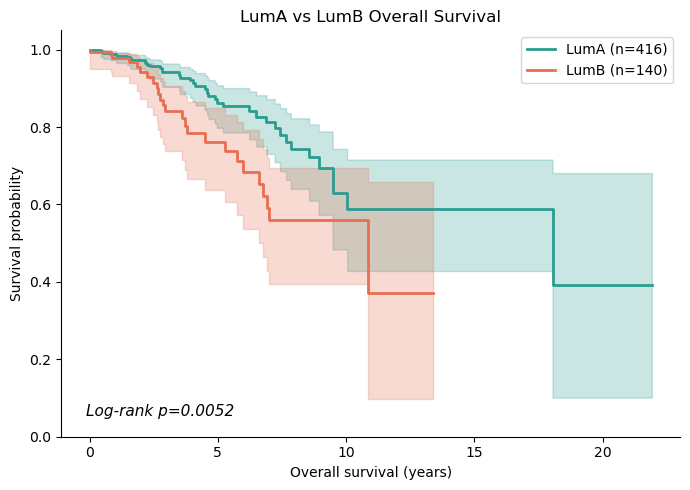

In [17]:
surv_common = surv.loc[surv.index.intersection(patients)]
surv_common = surv_common[surv_common["time"].notna() & (surv_common["time"]>0)].copy()
surv_common["time_years"] = surv_common["time"] / 365.25

kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(7, 5))
for st, color in [("LumA","#2a9d8f"),("LumB","#e76f51")]:
    sub = surv_common[surv_common["BRCA_Subtype_PAM50"]==st]
    kmf.fit(sub["time_years"], sub["event"], label=f"{st} (n={len(sub)})")
    kmf.plot_survival_function(ax=ax, ci_show=True, color=color, linewidth=2)
lr = logrank_test(
    surv_common.loc[surv_common["BRCA_Subtype_PAM50"]=="LumA","time_years"],
    surv_common.loc[surv_common["BRCA_Subtype_PAM50"]=="LumB","time_years"],
    event_observed_A=surv_common.loc[surv_common["BRCA_Subtype_PAM50"]=="LumA","event"],
    event_observed_B=surv_common.loc[surv_common["BRCA_Subtype_PAM50"]=="LumB","event"])
ax.text(0.04,0.05,f"Log-rank p={lr.p_value:.4f}",transform=ax.transAxes,fontsize=11,style="italic")
ax.set_xlabel("Overall survival (years)"); ax.set_ylabel("Survival probability")
ax.set_title("LumA vs LumB Overall Survival"); ax.set_ylim(0,1.05)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../results/figures/km_luma_vs_lumb_eda.png", dpi=300)
plt.show()

LumA and LumB have significantly different survival (log-rank p=0.0052), confirming the clinical
relevance of survival prediction in this cohort. However, the curves overlap substantially,
and many patients within each subtype have very different outcomes — motivating the question
of whether molecular features can explain within-subtype survival variation beyond the subtype label alone.